In [2]:
# setting up
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

In [3]:
# settings
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()
results_file = "./write/paul15.h5ad"
# low dpi (dots per inch) yields small inline figures
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor="white")

/tmp/ipykernel_9019/456379064.py:3: FutureWarning: Use `print_header` instead
  sc.logging.print_versions()
/tmp/ipykernel_9019/456379064.py:6: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor="white")


In [4]:
adata = sc.datasets.paul15()

In [5]:
# check object
adata

AnnData object with n_obs × n_vars = 2730 × 3451
    obs: 'paul15_clusters'
    uns: 'iroot'

In [6]:
# updating precision higher than float32 (this is not required and results will be comparable without it)
adata.X = adata.X.astype("float64")

In [7]:
# preprocessing and visualization
sc.pp.recipe_zheng17(adata)

running recipe zheng17
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
    finished (0:00:00)


/workspaces/Scanpy_Trajectory_Inference_Hematopoiesis/.venv/lib/python3.12/site-packages/scanpy/preprocessing/_recipes.py:185: FutureWarning: Use sc.pp.highly_variable_genes instead
  filter_result = filter_genes_dispersion(


In [8]:
sc.tl.pca(adata, svd_solver="arpack")

computing PCA
    with n_comps=50
    finished (0:00:00)


In [9]:
sc.pp.neighbors(adata, n_neighbors=4, n_pcs=20)
sc.tl.draw_graph(adata)

computing neighbors
    using 'X_pca' with n_pcs = 20


/workspaces/Scanpy_Trajectory_Inference_Hematopoiesis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:10)
drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fa', graph_drawing coordinates (adata.obsm) (0:00:17)


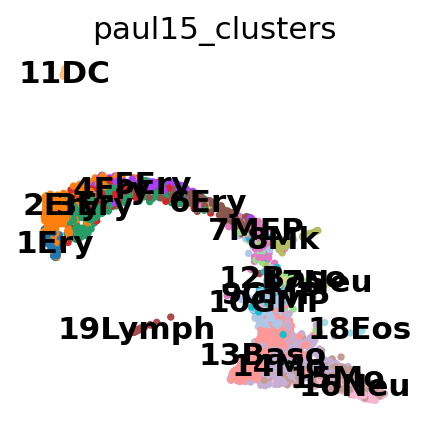

In [10]:
sc.pl.draw_graph(adata, color="paul15_clusters", legend_loc="on data")

In [11]:
# denoising the graph (optional) by representing it in diffusion map space (and not in PCA space)
sc.tl.diffmap(adata)
sc.pp.neighbors(adata, n_neighbors=10, use_rep="X_diffmap")

computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         1.         0.9989505  0.99597496 0.9939978  0.98925745
     0.9879414  0.98648685 0.9831232  0.98234713 0.9782109  0.9757828
     0.9739371  0.9737043  0.9637865 ]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


In [12]:
sc.tl.draw_graph(adata)

drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fa', graph_drawing coordinates (adata.obsm) (0:00:16)


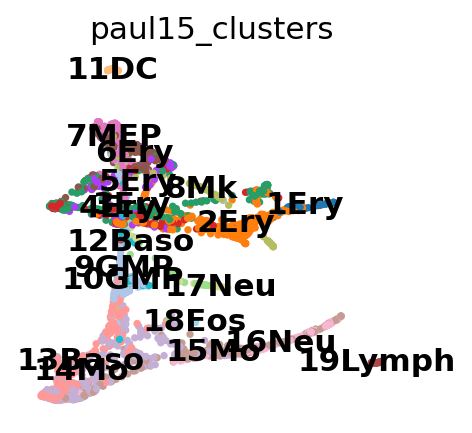

In [13]:
sc.pl.draw_graph(adata, color="paul15_clusters", legend_loc="on data")

In [ ]:
# clustering and PAGA (scverse tutorial says use louvain, but this is now deprecated)
sc.tl.leiden(adata, resolution=1.0)

/tmp/ipykernel_9019/1457446541.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=1.0)


running Leiden clustering
    finished: found 36 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


In [16]:
sc.tl.paga(adata, groups="leiden")

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


--> added 'pos', the PAGA positions (adata.uns['paga'])


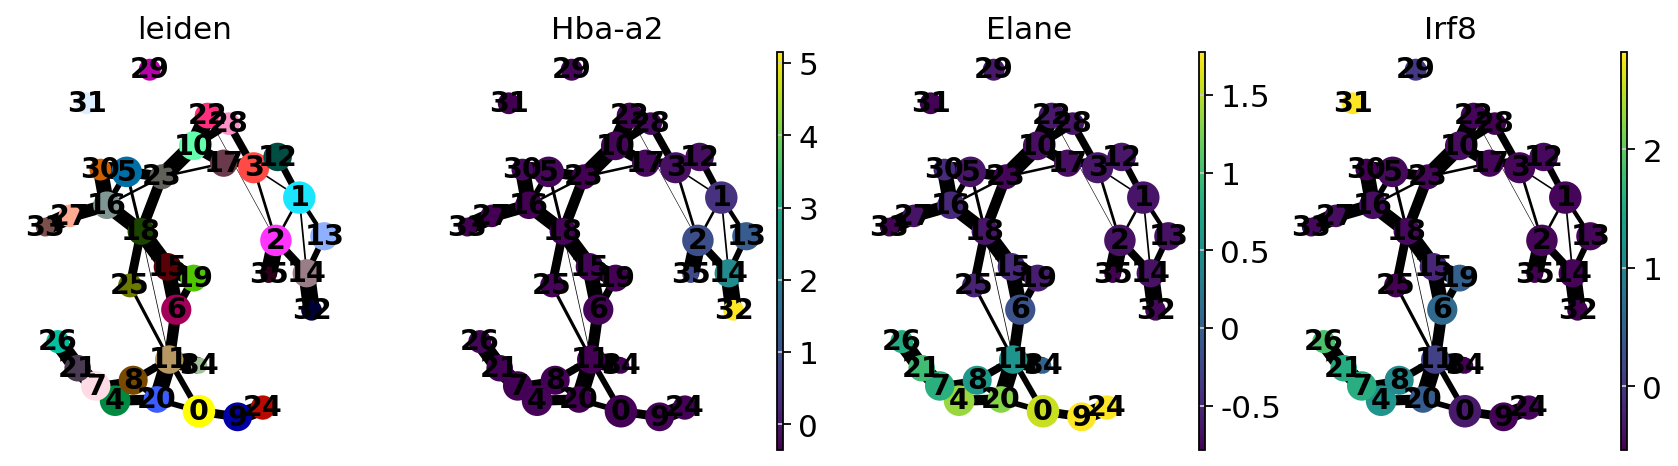

In [ ]:
# PAGA graph of hematopoietic trajectory colored by leiden clusters and lineage markers (Hba-a2, Elane, Irf8)
sc.pl.paga(adata, color=["leiden", "Hba-a2", "Elane", "Irf8"])

--> added 'pos', the PAGA positions (adata.uns['paga'])


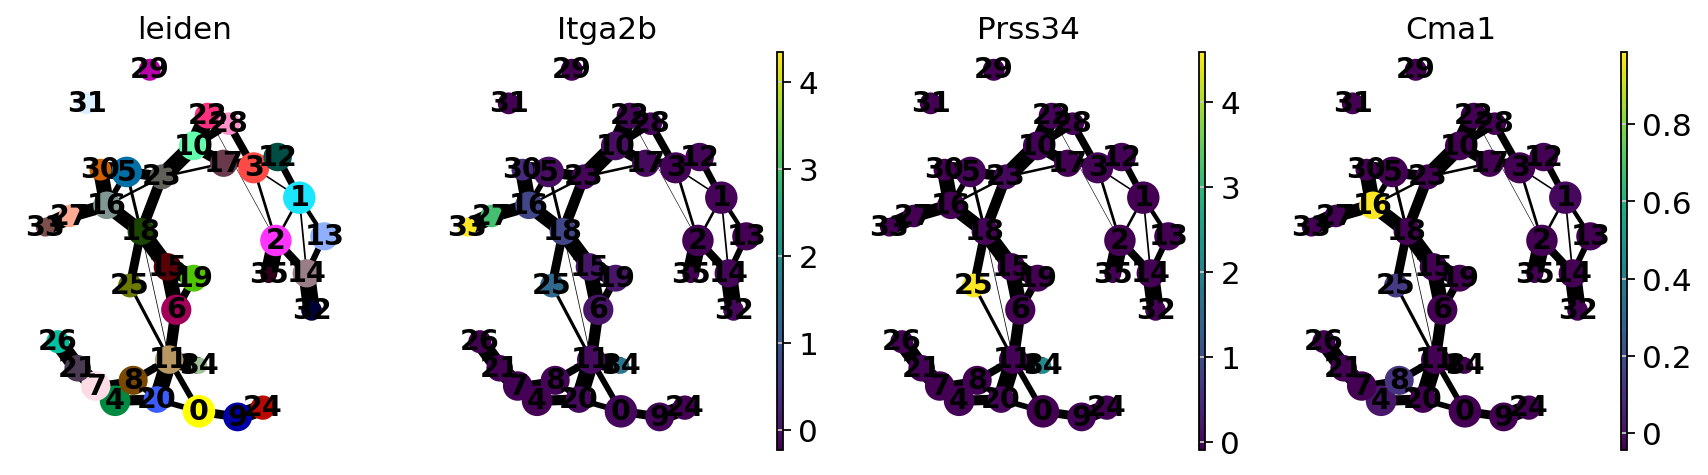

In [ ]:
PAGA graph colored by leiden clusters and megakaryocyte/mast cell markers (Itga2b, Prss34, Cma1)
sc.pl.paga(adata, color=["leiden", "Itga2b", "Prss34", "Cma1"])


In [19]:
# annotate
adata.obs["leiden"].cat.categories

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35'],
      dtype='object')

In [21]:
adata.obs["leiden_anno"] = adata.obs["leiden"].cat.rename_categories(
    {
        "10": "10/Ery",
        "16": "16/Stem",
        "19": "19/Neu",
        "20": "20/Mk",
        "22": "22/Baso",
        "24": "24/Mo",
    }
)

In [22]:
# use annotated clusters for PAGA 
sc.tl.paga(adata, groups="leiden_anno")

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


--> added 'pos', the PAGA positions (adata.uns['paga'])


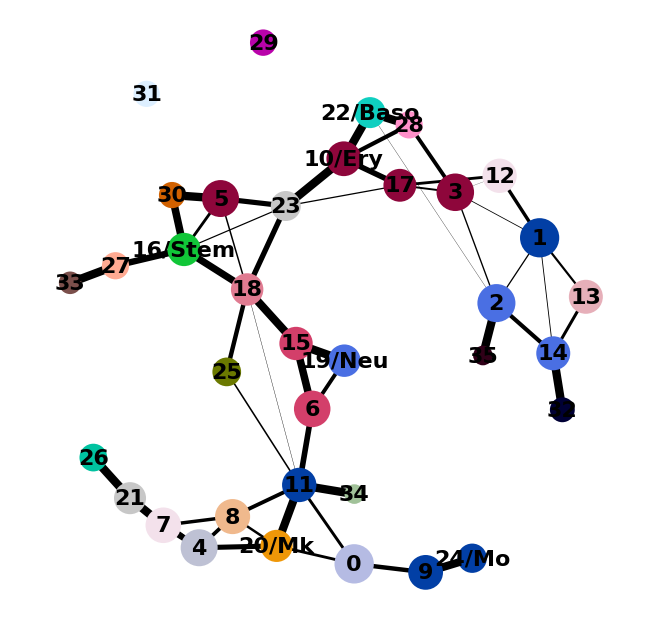

<Figure size 480x400 with 0 Axes>

In [38]:
# tutorial graph is unreadable so this is modified
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sc.pl.paga(adata, ax=ax, fontsize=10, node_size_scale=1.5, edge_width_scale=0.5)
plt.tight_layout()
plt.savefig("paga_annotated.png", dpi=300, bbox_inches="tight")

In [25]:
# recomputing the embedding using PAGA-initialization
sc.tl.draw_graph(adata, init_pos="paga")

drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fa', graph_drawing coordinates (adata.obsm) (0:00:15)


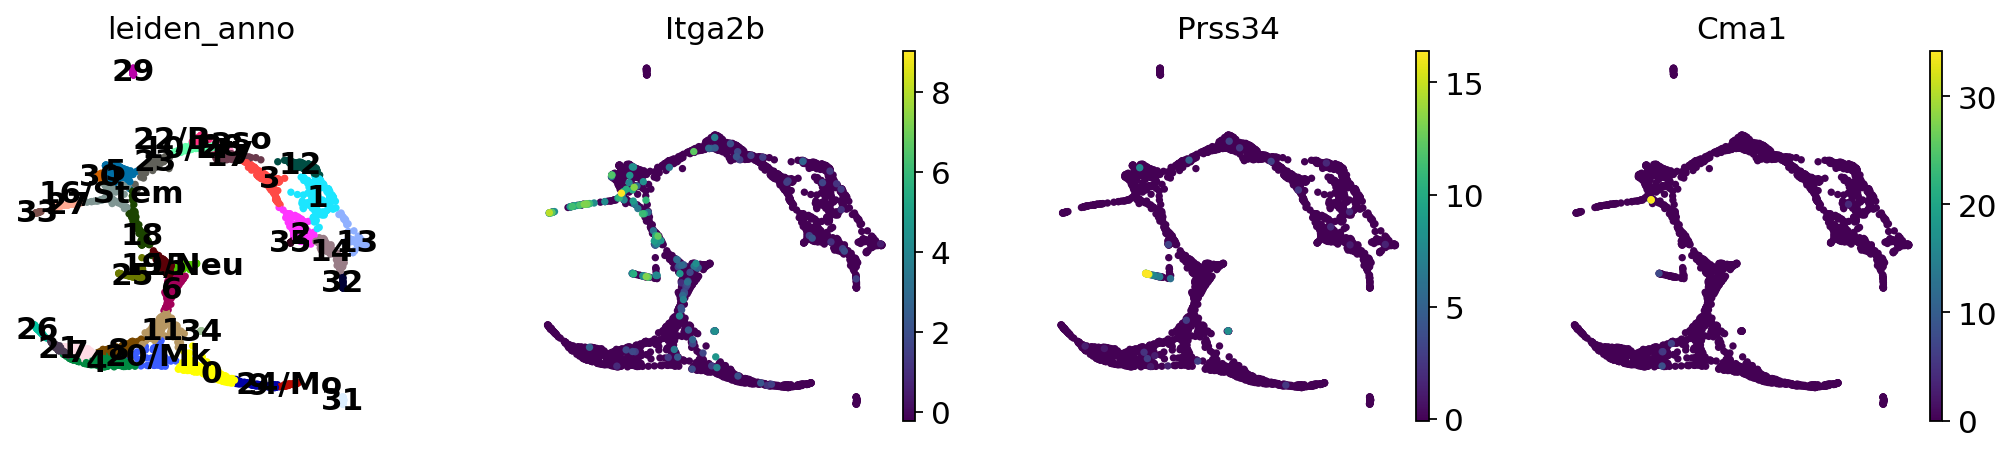

In [ ]:
# force-directed graph (ForceAtlas2) embeddings
sc.pl.draw_graph(adata, color=["leiden_anno", "Itga2b", "Prss34", "Cma1"], legend_loc="on data")


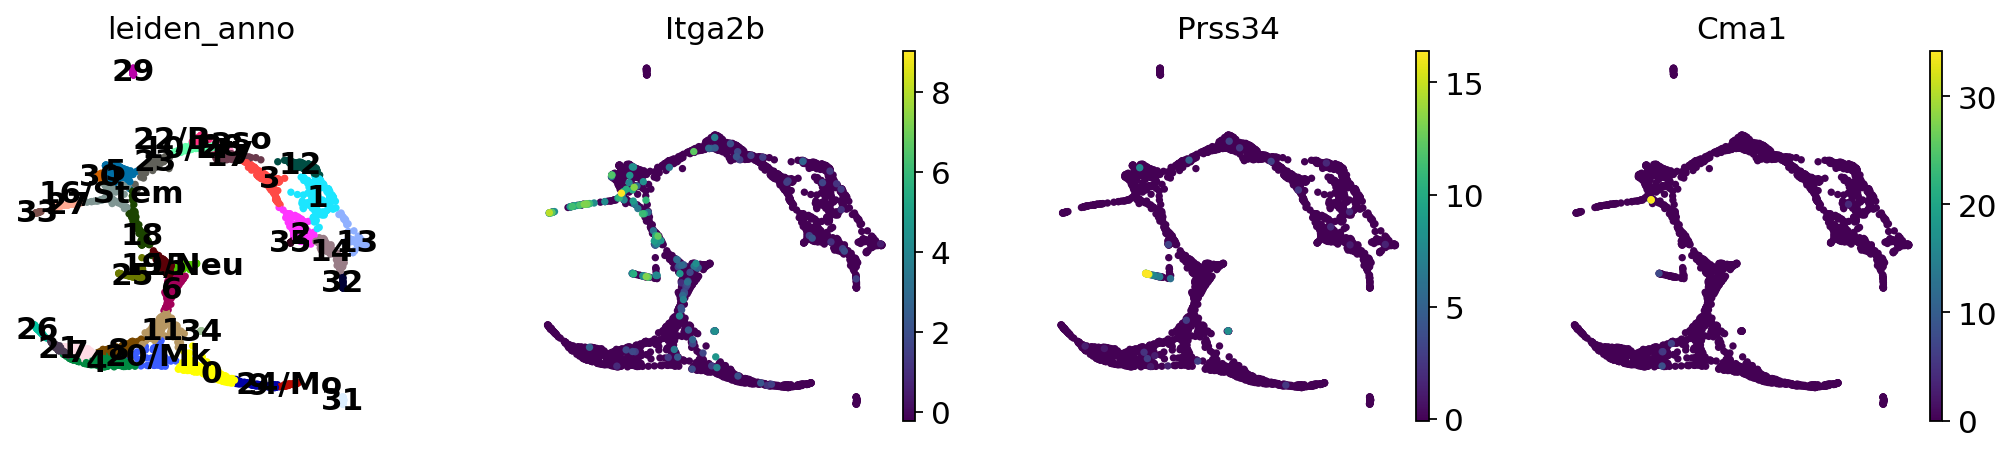

In [ ]:
# force-directed graph (ForceAtlas2) embeddings
sc.pl.draw_graph(adata, color=["leiden_anno", "Itga2b", "Prss34", "Cma1"], legend_loc="on data")


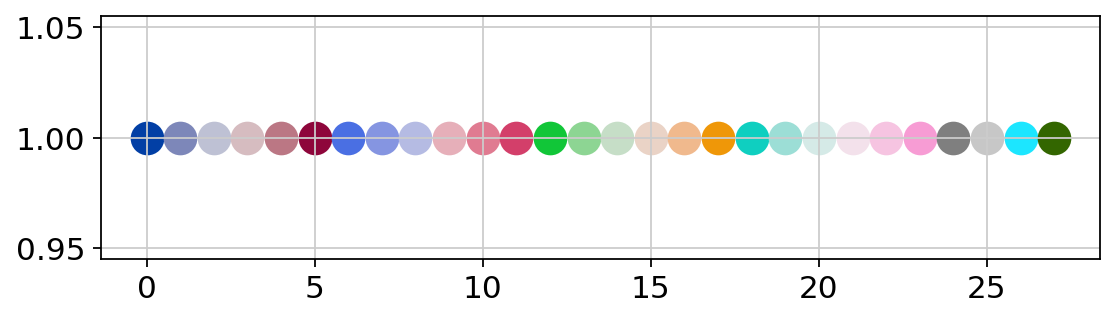

In [29]:
plt.figure(figsize=(8, 2))
for i in range(28):
    plt.scatter(i, 1, c=sc.pl.palettes.zeileis_28[i], s=200)
plt.show()

In [30]:
zeileis_colors = np.array(sc.pl.palettes.zeileis_28)
new_colors = np.array(adata.uns["leiden_anno_colors"])

In [31]:
new_colors[[16]] = zeileis_colors[[12]]  # Stem colors / green
new_colors[[10, 17, 5, 3, 15, 6, 18, 13, 7, 12]] = zeileis_colors[  # Ery colors / red
    [5, 5, 5, 5, 11, 11, 10, 9, 21, 21]
]
new_colors[[20, 8]] = zeileis_colors[[17, 16]]  # Mk early Ery colors / yellow
new_colors[[4, 0]] = zeileis_colors[[2, 8]]  # lymph progenitors / grey
new_colors[[22]] = zeileis_colors[[18]]  # Baso / turquoise
new_colors[[19, 14, 2]] = zeileis_colors[[6, 6, 6]]  # Neu / light blue
new_colors[[24, 9, 1, 11]] = zeileis_colors[[0, 0, 0, 0]]  # Mo / dark blue
new_colors[[21, 23]] = zeileis_colors[[25, 25]]  # outliers / grey

In [32]:
adata.uns["leiden_anno_colors"] = new_colors

--> added 'pos', the PAGA positions (adata.uns['paga'])


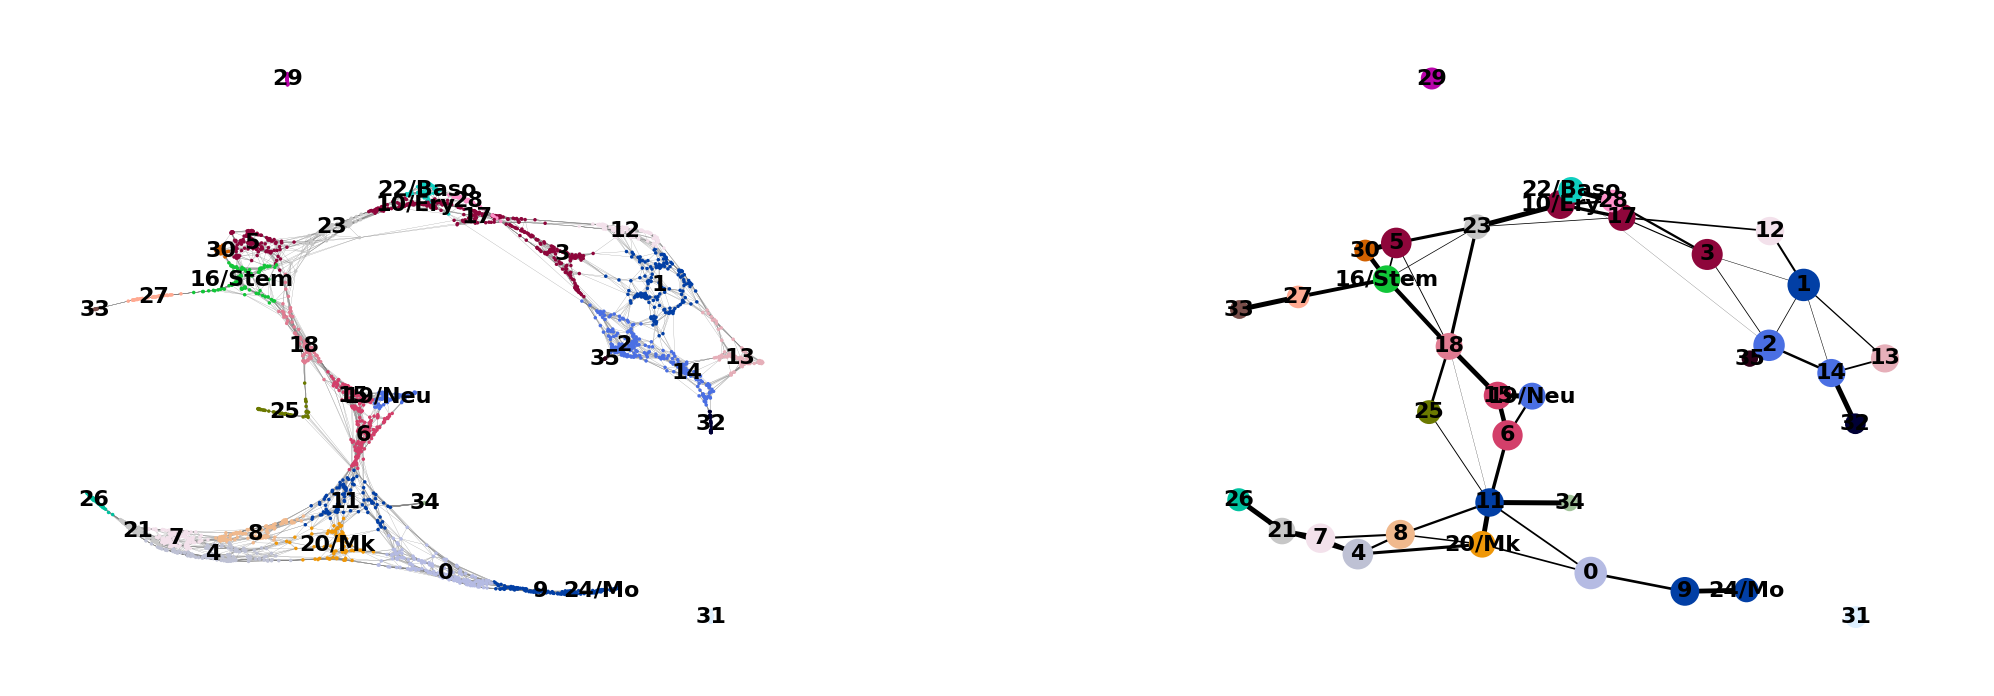

[<Axes: xlabel='FA1', ylabel='FA2'>, <Axes: >]

In [37]:
# again changes made here as scverse plot is not readable
plt.rcParams['figure.figsize'] = (6, 5)

sc.pl.paga_compare(
    adata,
    threshold=0.03,
    title="",
    right_margin=0.4,
    size=10,
    edge_width_scale=0.3,
    legend_fontsize=10,
    fontsize=8,
    frameon=False,
    edges=True,
)

In [39]:
# reconstructing gene changes along PAGA paths for a given set of genes
adata.uns["iroot"] = np.flatnonzero(adata.obs["leiden_anno"] == "16/Stem")[0]


In [40]:
sc.tl.dpt(adata)

computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)


In [41]:
gene_names = [
    *["Gata2", "Gata1", "Klf1", "Epor", "Hba-a2"],  # erythroid
    *["Elane", "Cebpe", "Gfi1"],  # neutrophil
    *["Irf8", "Csf1r", "Ctsg"],  # monocyte
]

In [42]:
adata_raw = sc.datasets.paul15()
sc.pp.log1p(adata_raw)
sc.pp.scale(adata_raw)
adata.raw = adata_raw


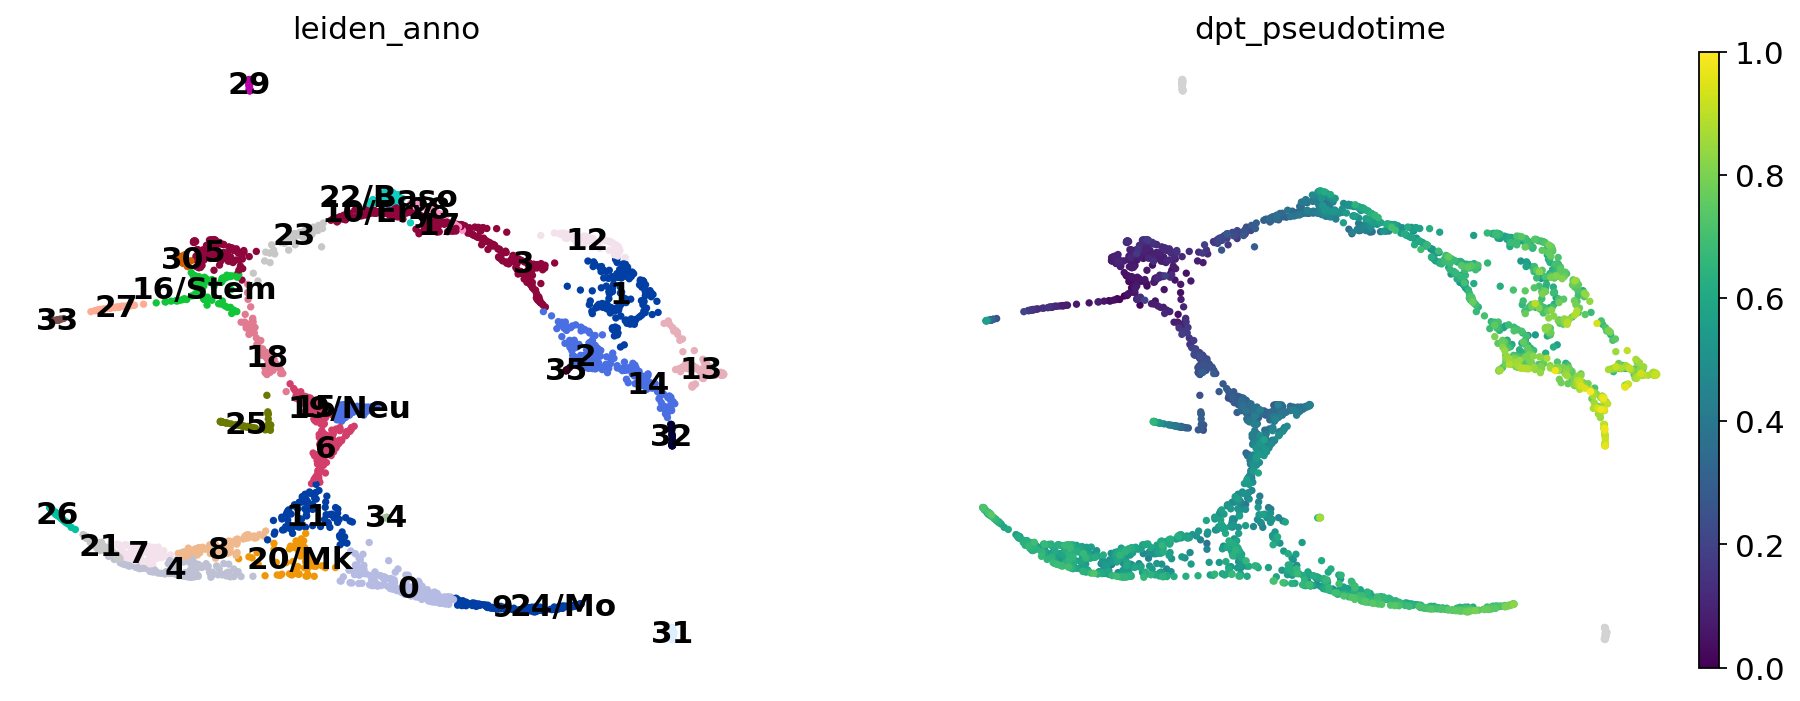

In [43]:
sc.pl.draw_graph(adata, color=["leiden_anno", "dpt_pseudotime"], legend_loc="on data")


In [44]:
paths = [
    ("erythrocytes", [16, 12, 7, 13, 18, 6, 5, 10]),
    ("neutrophils", [16, 0, 4, 2, 14, 19]),
    ("monocytes", [16, 0, 4, 11, 1, 9, 24]),
]

In [45]:
adata.obs["distance"] = adata.obs["dpt_pseudotime"]

In [46]:
adata.obs["clusters"] = adata.obs["leiden_anno"]

In [47]:
adata.uns["clusters_colors"] = adata.uns["leiden_anno_colors"]

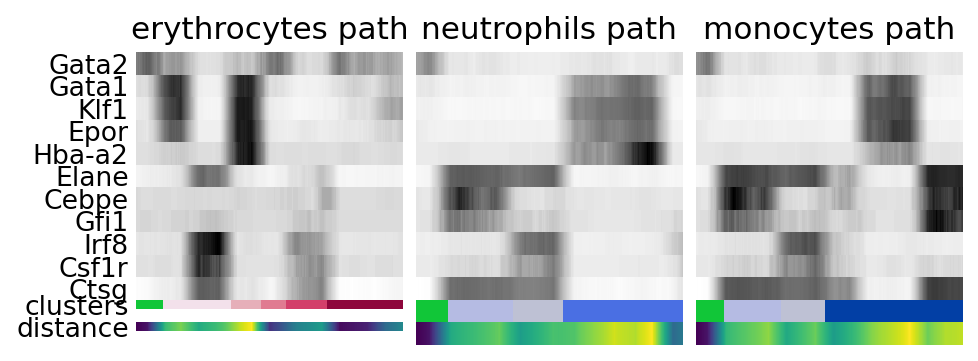

In [ ]:
# PAGA path heatmap showing how marker gene expression changes along three differentiation paths from stem cells to each lineage
_, axs = plt.subplots(ncols=3, figsize=(6, 2.5), gridspec_kw={"wspace": 0.05, "left": 0.12})
plt.subplots_adjust(left=0.05, right=0.98, top=0.82, bottom=0.2)
for ipath, (descr, path) in enumerate(paths):
    data = sc.pl.paga_path(
        adata,
        path,
        gene_names,
        show_node_names=False,
        ax=axs[ipath],
        ytick_fontsize=12,
        left_margin=0.15,
        n_avg=50,
        annotations=["distance"],
        show_yticks=ipath == 0,
        show_colorbar=False,
        color_map="Greys",
        groups_key="clusters",
        color_maps_annotations={"distance": "viridis"},
        title=f"{descr} path",
        return_data=True,
        show=False,
    )

